# Dynamic fusion correctness groups
Generate the four-group figure used in Section 6.2 directly from `dynamic_test_predictions.csv`. This standalone notebook reproduces the layout and colors of figure 15 in `dynamic_error_analysis.ipynb`; no training, raw images, or other notebook execution is needed.

**Use:** place this notebook in `6_discussion/multimodal-analysis/` and run all cells. It also works with the kernel started at the repository root or any directory inside it. If running elsewhere, set `REPO_ROOT` below. Dependencies: NumPy, pandas, and Matplotlib (plus Jupyter to run the notebook).

Counts refer to aligned camera-view rows. Each FEA prediction appears twice, once per view of the same reenactment; these are not independent FEA observations. Percentages are normalized separately within each correctness group. No dataset or image outputs are embedded in this distributed notebook.

## 1. Paths and appearance
All presentation settings are collected here. Set `title=""` to remove the in-figure title for publication. Reduce `figsize` height to make the rows more compact. Rerun the plotting/export cell after changing `STYLE`; rerun all cells after changing the input path.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

REPO_ROOT = '/workspace/repos/emohevrdb-dfer/' # None: search the working directory and its parents; otherwise Path("/path/to/emohevrdb-dfer").
PREDICTIONS_RELATIVE = Path("6_discussion/multimodal-analysis/dynamic_test_predictions.csv")
OUTPUT_RELATIVE = Path("6_discussion/multimodal-analysis/outputs/figures")
FIGURE_STEM = "dynamic_fusion_correctness_groups"
EXPORT_FORMATS = ("pdf",)  # For an additional preview: ("pdf", "png").
EXPORT_DPI = 300
EXPORT_PAD_INCHES = 0.0

GROUP_LABELS = {
    "both_correct": "Both unimodal models correct",
    "image_only_correct": "Only Image correct",
    "fea_only_correct": "Only FEA correct",
    "both_wrong": "Both unimodal models wrong",
}


## 2. Load and check the paired predictions
The repository CSV already contains both views. Do not deduplicate it or duplicate FEA rows again. Checks below prevent missing labels, repeated view rows, or inconsistent FEA predictions from silently changing the comparison.

In [2]:
if REPO_ROOT is None:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    repo_root = next((p for p in candidates if (p / PREDICTIONS_RELATIVE).is_file()), None)
    if repo_root is None:
        raise FileNotFoundError("Cannot locate the prediction CSV. Run inside emohevrdb-dfer or set REPO_ROOT.")
else:
    repo_root = Path(REPO_ROOT).expanduser().resolve()

prediction_path = repo_root / PREDICTIONS_RELATIVE
output_dir = repo_root / OUTPUT_RELATIVE
required = ["sample_id", "reenactment_id", "camera_index", "true_label_id",
            "image_pred_id", "fea_pred_id", "multimodal_pred_id"]
predictions = pd.read_csv(prediction_path, usecols=required)
if predictions.empty or predictions[required].isna().any().any():
    raise ValueError("Predictions must be nonempty and contain no missing required values.")
if predictions["sample_id"].duplicated().any() or predictions.duplicated(["reenactment_id", "camera_index"]).any():
    raise ValueError("Each camera view must occur once per reenactment.")
label_columns = ["true_label_id", "image_pred_id", "fea_pred_id", "multimodal_pred_id"]
if not predictions[label_columns].isin(range(7)).all().all():
    raise ValueError("Expected integer class IDs from 0 to 6.")
paired = predictions.groupby("reenactment_id")
if not paired.size().eq(2).all() or not predictions["camera_index"].isin([0, 1]).all():
    raise ValueError("Expected central (0) and side (1) rows for each reenactment.")
if not paired[["true_label_id", "fea_pred_id"]].nunique().eq(1).all().all():
    raise ValueError("Reference labels and FEA predictions must agree across paired views.")
print(f"Loaded {len(predictions)} view rows from {paired.ngroups} reenactments.")
print(f"Input: {prediction_path}")

Loaded 756 view rows from 378 reenactments.
Input: /workspace/repos/emohevrdb-dfer/6_discussion/multimodal-analysis/dynamic_test_predictions.csv


## 3. Summarize fusion outcomes
Groups depend only on Image and FEA correctness. Fusion is then evaluated within each group. An empty group has an undefined accuracy and is labeled explicitly. Counts are recomputed from the CSV, not hard-coded from the paper.

In [3]:
image_correct = predictions["image_pred_id"].eq(predictions["true_label_id"])
fea_correct = predictions["fea_pred_id"].eq(predictions["true_label_id"])
fusion_correct = predictions["multimodal_pred_id"].eq(predictions["true_label_id"])
group_masks = {
    "both_correct": image_correct & fea_correct,
    "image_only_correct": image_correct & ~fea_correct,
    "fea_only_correct": ~image_correct & fea_correct,
    "both_wrong": ~image_correct & ~fea_correct,
}
records = []
for group, mask in group_masks.items():
    n = int(mask.sum())
    correct = int((mask & fusion_correct).sum())
    records.append(dict(group=group, n=n, correct=correct, wrong=n-correct,
                        correct_percent=100 * correct / n if n else np.nan))
summary = pd.DataFrame(records).set_index("group")
assert summary["n"].sum() == len(predictions)
assert summary["correct"].sum() == fusion_correct.sum()
display(summary.round(2))

,n,correct,wrong,correct_percent
group,,,,
both_correct,476,474,2,99.58
image_only_correct,74,52,22,70.27
fea_only_correct,116,86,30,74.14
both_wrong,90,5,85,5.56


## 4. Plot
The green segment shows correct fusion predictions and the gray segment shows incorrect ones. Small segments omit their internal count to avoid crowding; the right-hand summary always reports both counts. The plotting function returns a Matplotlib Figure and does not change the analysis.

In [4]:
def plot_fusion_groups(summary, style, group_labels):
    """Draw within-group percentages with counts and centered two-line summaries."""
    s = style
    if not 0 < s["bar_height"] <= 1 or not 0 < s["x_tick_step"] <= 100:
        raise ValueError("Use bar_height in (0, 1] and x_tick_step in (0, 100].")

    positions = np.arange(len(summary))
    sizes = summary["n"].to_numpy(dtype=int)
    correct = summary["correct"].to_numpy(dtype=int)
    wrong = summary["wrong"].to_numpy(dtype=int)
    pct = summary["correct_percent"].fillna(0).to_numpy()
    wrong_pct = np.where(sizes > 0, 100 - pct, 0)

    rc = {
        "font.family": s["font_family"],
        "figure.dpi": s["figure_dpi"],
        "text.color": s["text_color"],
        "axes.labelcolor": s["text_color"],
        "xtick.color": s["text_color"],
        "ytick.color": s["text_color"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }

    with plt.rc_context(rc):
        fig, ax = plt.subplots(
            figsize=s["figsize"], layout="constrained", facecolor=s["facecolor"]
        )
        ax.set_facecolor(s["facecolor"])

        bar_options = dict(
            height=s["bar_height"],
            edgecolor=s["bar_edge_color"],
            linewidth=s["bar_edge_width"],
            zorder=3,
        )
        ax.barh(
            positions, pct, color=s["correct_color"],
            label=s["correct_label"], **bar_options
        )
        ax.barh(
            positions, wrong_pct, left=pct, color=s["wrong_color"],
            label=s["wrong_label"], **bar_options
        )

        for y, n, nc, nw, pc, pw in zip(positions, sizes, correct, wrong, pct, wrong_pct):
            # Internal counts are shown only when their segment is wide enough.
            if s["show_segment_counts"] and n:
                segments = [
                    (pc / 2, pc, nc, s["correct_text_color"]),
                    (pc + pw / 2, pw, nw, s["wrong_text_color"]),
                ]
                for center, width, count, color in segments:
                    if count and width >= s["segment_min_percent"]:
                        ax.text(
                            center, y, str(count),
                            ha="center", va="center", color=color,
                            fontsize=s["count_fontsize"], fontweight=s["count_weight"],
                        )

            if not n:
                ax.text(
                    50, y, "Empty group",
                    ha="center", va="center", color=s["detail_color"],
                )

            # Center the complete two-line summary vertically on the bar.
            if s["show_right_summary"]:
                rate = (
                    f"{pc:.{s['rate_decimals']}f}%\n{s['rate_label']}"
                    if n else "Empty\ngroup"
                )
                ax.text(
                    s["summary_x"], y, rate,
                    transform=ax.get_yaxis_transform(),
                    ha="left", va="center", multialignment="center",
                    linespacing=s["rate_linespacing"],
                    fontsize=s["rate_fontsize"], fontweight=s["rate_weight"],
                    color=s["text_color"], clip_on=False,
                )

        labels = [
            group_labels[group]
            + ("\n" + s["group_size_template"].format(n=n) if s["show_group_sizes"] else "")
            for group, n in zip(summary.index, sizes)
        ]
        ax.set_yticks(
            positions, labels=labels,
            fontsize=s["y_tick_fontsize"], fontweight=s["y_tick_weight"],
        )
        ax.invert_yaxis()
        ax.set_xlim(0, 100)
        ax.set_xticks(np.unique(np.append(np.arange(0, 100, s["x_tick_step"]), 100)))
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

        # Configure X-axis tick marks independently of their labels.
        ax.tick_params(
            axis="x",
            which="major",
            bottom=s["show_x_ticks"],
            top=False,
            labelbottom=True,
            labeltop=False,
            length=s["x_tick_length"],
            width=s["x_tick_width"],
            direction=s["x_tick_direction"],
            color=s["x_tick_color"],
            labelcolor=s["text_color"],
            labelsize=s["x_tick_fontsize"],
            pad=s["x_tick_pad"],
        )
        for label in ax.get_xticklabels():
            label.set_fontweight(s["x_tick_weight"])

        # Configure Y-axis tick marks independently of their labels.
        ax.tick_params(
            axis="y",
            which="major",
            left=s["show_y_ticks"],
            right=False,
            labelleft=True,
            labelright=False,
            length=s["y_tick_length"],
            width=s["y_tick_width"],
            direction=s["y_tick_direction"],
            color=s["y_tick_color"],
            labelcolor=s["text_color"],
            labelsize=s["y_tick_fontsize"],
            pad=s["y_tick_pad"],
        )
        ax.minorticks_off()

        ax.set_xlabel(
            s["xlabel"], fontsize=s["label_fontsize"],
            fontweight=s["label_weight"], labelpad=s["label_pad"],
        )
        if s["title"]:
            ax.set_title(
                s["title"], loc="left", fontsize=s["title_fontsize"],
                fontweight=s["title_weight"], pad=s["title_pad"],
            )

        ax.set_axisbelow(True)
        ax.grid(False)
        if s["show_grid"]:
            ax.grid(axis="x", color=s["grid_color"], linewidth=s["grid_linewidth"])

        # Hide axis lines while retaining independently configured tick marks.
        for spine in ax.spines.values():
            spine.set_visible(False)

        if s["show_legend"]:
            ax.legend(
                loc="upper center", bbox_to_anchor=s["legend_anchor"],
                ncol=2, frameon=False, fontsize=s["legend_fontsize"],
            )

    return fig

## 5. Export and display
Run this cell again after changing `STYLE`. Existing files with the configured stem are replaced. The default output is a vector PDF; copy it into the paper's `assets/` directory. The supplied LaTeX section uses a two-column `figure*` to preserve readability.

In [8]:
GROUP_LABELS = {
    "both_correct": "Both correct",       # Both unimodal models are correct.
    "image_only_correct": "Image only",   # Only the image model is correct.
    "fea_only_correct": "FEA only",       # Only the FEA model is correct.
    "both_wrong": "Both wrong",           # Both unimodal models are incorrect.
}

STYLE = dict(
    # Figure dimensions and background.
    figsize=(6, 3),                      # Figure width and height in inches.
    figure_dpi=120,                      # Notebook display resolution.
    font_family="DejaVu Sans",           # Font family for all text.
    facecolor="white",                   # Figure and plotting-area background.

    # Colors.
    correct_color="#007A5E",             # Fill color for correct fusion predictions.
    wrong_color="#D9DEE5",               # Fill color for incorrect fusion predictions.
    text_color="#262626",                # Default text and tick-label color.
    correct_text_color="white",          # Count color inside correct segments.
    wrong_text_color="#263238",          # Count color inside incorrect segments.
    detail_color="#59636E",              # Text color for empty groups.

    # Bar geometry.
    bar_height=0.8,                      # Bar height relative to the spacing between rows.
    bar_edge_color="white",              # Color of bar outlines.
    bar_edge_width=0.8,                  # Bar-outline width in points.

    # Counts inside bars.
    show_segment_counts=True,           # Show counts inside sufficiently wide segments.
    segment_min_percent=12,             # Minimum segment width (%) for an internal count.
    count_fontsize=12,                   # Internal count font size in points.
    count_weight="bold",                 # Internal count weight: "normal" or "bold".

    # Group sizes beneath row labels.
    show_group_sizes=True,               # Show each group's size beneath its label.
    group_size_template="n = {n}",       # Format of the group-size line.

    # X-axis ticks.
    show_x_ticks=False,                   # Show bottom tick marks; labels remain visible.
    x_tick_length=0,                     # Tick-mark length in points.
    x_tick_width=0,                    # Tick-mark width in points.
    x_tick_direction="out",              # Tick direction: "in", "out", or "inout".
    x_tick_color="#262626",              # Tick-mark color, independent of label color.
    x_tick_fontsize=8,                   # X-axis tick-label font size in points.
    x_tick_weight="normal",              # X-axis tick-label font weight.
    x_tick_pad=2,                        # Distance between tick marks and labels in points.
    x_tick_step=25,                      # Tick spacing in percentage points.

    # Y-axis ticks.
    show_y_ticks=True,                   # Show left tick marks; labels remain visible.
    y_tick_length=4,                     # Tick-mark length in points.
    y_tick_width=1.0,                    # Tick-mark width in points.
    y_tick_direction="out",              # Tick direction: "in", "out", or "inout".
    y_tick_color="#262626",              # Tick-mark color, independent of label color.
    y_tick_fontsize=10,                   # Font size of group labels and group sizes.
    y_tick_weight="bold",                # Font weight of the complete Y-axis tick labels.
    y_tick_pad=2,                        # Distance between tick marks and labels in points.

    # X-axis title.
    xlabel="Within-group percentage",    # X-axis title text.
    label_fontsize=10,                    # X-axis title font size in points.
    label_weight="bold",                 # X-axis title font weight.
    label_pad=2,                         # Distance between tick labels and the axis title.

    # Optional figure title.
    title="",                           # Leave empty when using a LaTeX caption.
    title_fontsize=13,                   # Font size of an enabled figure title.
    title_weight="bold",                 # Figure-title font weight.
    title_pad=18,                        # Space between title and axes in points.

    # Two-line summaries on the right.
    show_right_summary=True,             # Show the percentage and the text beneath it.
    summary_x=1.008,                     # Left text edge; 1 is the axes' right boundary.
    rate_fontsize=10,                     # Font size of both summary lines.
    rate_weight="bold",                  # Font weight of both summary lines.
    rate_decimals=1,                     # Decimal places in the percentage.
    rate_label="Correct",                # Text displayed beneath the percentage.
    rate_linespacing=1.5,                # Line spacing within the centered text block.

    # Legend.
    correct_label="Fusion Correct",      # Legend label for correct predictions.
    wrong_label="Fusion Wrong",          # Legend label for incorrect predictions.
    show_legend=True,                    # Show the legend.
    legend_fontsize=9,                   # Legend font size in points.
    legend_anchor=(0.5, 1.1),            # Legend position relative to the plotting area.

    # Grid.
    show_grid=True,                      # Show vertical grid lines.
    grid_color="#b0b0b0",                # Grid-line color.
    grid_linewidth=0.8,                  # Grid-line width in points.
)

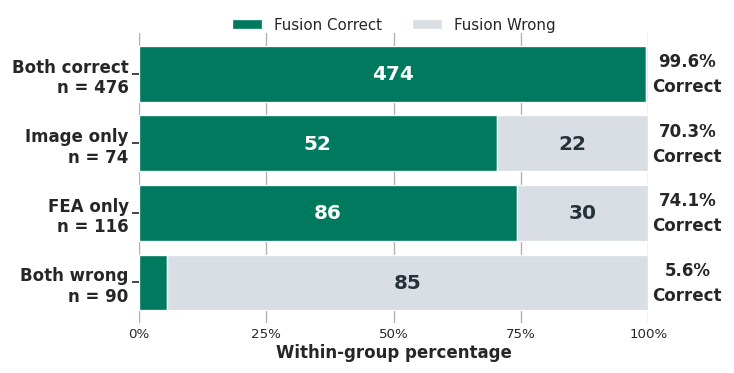

In [9]:
fig = plot_fusion_groups(summary, STYLE, GROUP_LABELS)
plt.show()

In [10]:
output_dir.mkdir(parents=True, exist_ok=True)
for extension in EXPORT_FORMATS:
    path = output_dir / f"{FIGURE_STEM}.{extension}"
    fig.savefig(path, dpi=EXPORT_DPI, bbox_inches="tight", pad_inches=EXPORT_PAD_INCHES)
    print(f"Exported: {path}")

plt.close(fig)

Exported: /workspace/repos/emohevrdb-dfer/6_discussion/multimodal-analysis/outputs/figures/dynamic_fusion_correctness_groups.pdf
